# Rising- Versus Falling-Flank c-GC Across Preprocessing Cases

This overview loads the four supplied motoneuron preprocessing cases and computes rising- versus falling-flank c-GC through the `CausalGranger` adapter over `core.rising_flanks.RisingFlanks`.

The notebook has three end-stage cells after fitting:

1. save weighted retained adjacency matrices to a `.pkl` cache;
2. optionally reload the weighted cache without recomputing c-GC;
3. reproduce the manuscript Figure 4/5-style abstract bilateral panels, not anatomical background plots.

The saved `adjacency` matrices are weighted retained c-GC score matrices in `[source, target]` orientation. Zero means no retained edge.


In [1]:
from pathlib import Path
import os
import pickle
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif (PROJECT_ROOT / "calcium-transient-rising-flank").exists():
    PROJECT_ROOT = PROJECT_ROOT / "calcium-transient-rising-flank"
SRC = PROJECT_ROOT / "src"
CORE = SRC / "core"
for path in (SRC, CORE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from calcium_transient_rising_flank import (
    CausalGranger,
    build_representations,
    plot_directed_graph,
    selected_frame_indices,
)
from others_funcs import get_ratio_from_GC

TRACE_KEYS = ((3, 1), (3, 2), (5, 2))
PLOT_KEYS = ((3, 1), (5, 2), (3, 2))
MAX_LAG = 3
N_PERMUTATIONS = int(os.environ.get("RF_N_PERMUTATIONS", "1000"))
SIGNIFICANCE_ALPHA = 0.01
RANDOM_STATE = 10
DATA_DIR = PROJECT_ROOT / "data" / "motoneurons"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ADJACENCY_OUTPUT_FILE = OUTPUT_DIR / "rising_flanks_weighted_adjacency_matrices.pkl"
FIGURE_DIR = PROJECT_ROOT.parent / "figures"

CASE_FILES = {
    "A": ("dff_dict_with_bad_neurons.pkl", "middle_dict.pkl", "bad neurons and artefacts retained"),
    "B": ("dff_removed_dict.pkl", "middle_removed_dict.pkl", "bad neurons removed; artefacts retained"),
    "C": ("dff_corrected_dict.pkl", "middle_removed_dict.pkl", "bad neurons and artefacts removed"),
    "D": ("dff_smoothed_dict.pkl", "middle_removed_dict.pkl", "corrected traces smoothed"),
}
CASE_FIGURE_INDEX = {"A": 1, "B": 2, "C": 3, "D": 4}


/Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_pickle(filename):
    with (DATA_DIR / filename).open("rb") as handle:
        return pickle.load(handle)


def load_case(trace_file, middle_file):
    trace_store = load_pickle(trace_file)
    middle_store = load_pickle(middle_file)
    traces = {key: np.asarray(trace_store[key], dtype=float) for key in TRACE_KEYS}
    middle = {key: int(middle_store[key]) for key in TRACE_KEYS}
    return traces, middle


cases = {}
total_cases = len(CASE_FILES)
for index, (label, (trace_file, middle_file, description)) in enumerate(CASE_FILES.items(), start=1):
    print(f"[{index}/{total_cases}] Loading case {label}: {description}...", flush=True)
    traces, middle = load_case(trace_file, middle_file)
    cases[label] = {"description": description, "traces": traces, "middle": middle}
    shapes = {key: values.shape for key, values in traces.items()}
    print(f"[{index}/{total_cases}] Loaded case {label}; {shapes}", flush=True)


[1/4] Loading case A: bad neurons and artefacts retained...
[1/4] Loaded case A; {(3, 1): (14, 1000), (3, 2): (11, 1000), (5, 2): (19, 1000)}
[2/4] Loading case B: bad neurons removed; artefacts retained...
[2/4] Loaded case B; {(3, 1): (14, 1000), (3, 2): (11, 1000), (5, 2): (17, 1000)}
[3/4] Loading case C: bad neurons and artefacts removed...
[3/4] Loaded case C; {(3, 1): (14, 1000), (3, 2): (11, 1000), (5, 2): (17, 1000)}
[4/4] Loading case D: corrected traces smoothed...
[4/4] Loaded case D; {(3, 1): (14, 1000), (3, 2): (11, 1000), (5, 2): (17, 1000)}


## Visualize Extracted Rising Flanks on Raw Motoneuron Transient

This cell overlays the extracted rising-flank samples as red markers on a representative raw motoneuron calcium transient.  It is intentionally placed before the c-GC fitting cells so the extraction can be inspected without rerunning the full network analysis.


Plotted ROI 1; visible rising samples=95; total rising samples=309
Saved /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/rising_flank_overlay_motoneuron_caseD_F5T2.pdf
Saved /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/rising_flank_overlay_motoneuron_caseD_F5T2.png


(<Figure size 1008x364 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='Fluorescence (a.u.)'>)

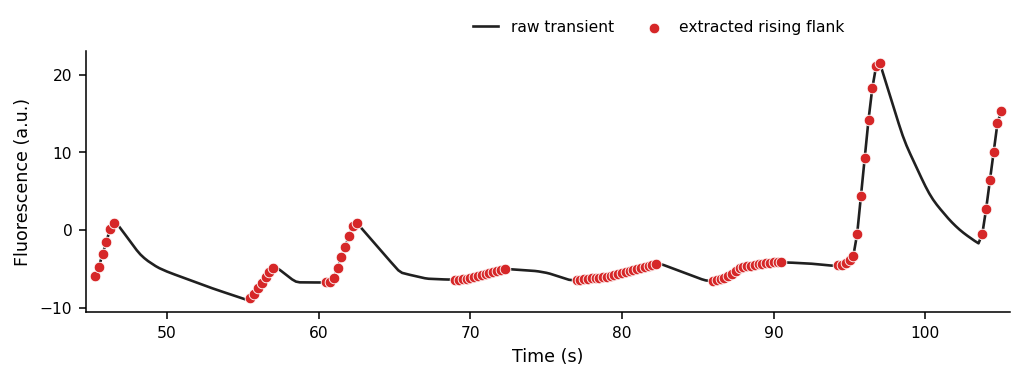

In [3]:
# Paper-ready overlay of extracted rising flanks on a raw motoneuron transient.
# Defaults: Case D, Fish 5 Trace 2. Override with RF_RISE_PLOT_CASE, RF_RISE_PLOT_KEY,
# RF_RISE_PLOT_ROI, RF_RISE_WINDOW_SECONDS, or RF_MOTORNEURON_SAMPLING_HZ.

MOTOR_RISE_PLOT_CASE = os.environ.get("RF_RISE_PLOT_CASE", "D")
MOTOR_RISE_PLOT_KEY = tuple(
    int(value.strip())
    for value in os.environ.get("RF_RISE_PLOT_KEY", "5,2").split(",")
)
MOTOR_RISE_PLOT_ROI = os.environ.get("RF_RISE_PLOT_ROI")
MOTOR_RISE_WINDOW_SECONDS = float(os.environ.get("RF_RISE_WINDOW_SECONDS", "60"))
MOTORNEURON_SAMPLING_HZ = float(os.environ.get("RF_MOTORNEURON_SAMPLING_HZ", "4.0"))
SHOW_RISE_OVERLAY_TITLE = os.environ.get("RF_RISE_SHOW_TITLE", "0").lower() in {"1", "true", "yes"}


def _representative_roi(rise):
    event_counts = np.asarray([len(indices) for indices in selected_frame_indices(rise)], dtype=int)
    event_weight = rise.sum(axis=1)
    if event_counts.max(initial=0) == 0:
        return int(np.argmax(np.ptp(rise, axis=1)))
    return int(np.lexsort((event_weight, event_counts))[-1])


def _event_dense_window(event_indices, n_frames, window_frames):
    window_frames = int(min(max(window_frames, 20), n_frames))
    if window_frames >= n_frames or len(event_indices) == 0:
        return 0, n_frames
    binary = np.zeros(n_frames, dtype=float)
    binary[np.asarray(event_indices, dtype=int)] = 1.0
    scores = np.convolve(binary, np.ones(window_frames, dtype=float), mode="valid")
    start = int(np.argmax(scores))
    return start, start + window_frames


def plot_raw_trace_with_rising_flanks(
    traces,
    *,
    sampling_hz,
    title,
    output_stem,
    roi_index=None,
    window_seconds=60.0,
):
    values = np.asarray(traces, dtype=float)
    representations = build_representations(values)
    rise = representations.rise
    event_indices = selected_frame_indices(rise)
    roi = _representative_roi(rise) if roi_index is None else int(roi_index)
    if roi < 0 or roi >= values.shape[0]:
        raise ValueError(f"roi_index={roi} is outside the available range 0..{values.shape[0] - 1}")

    event_frames = np.asarray(event_indices[roi], dtype=int)
    start, stop = _event_dense_window(
        event_frames,
        values.shape[1],
        int(round(window_seconds * sampling_hz)),
    )
    visible_events = event_frames[(event_frames >= start) & (event_frames < stop)]
    time = np.arange(start, stop, dtype=float) / sampling_hz

    with plt.rc_context(
        {
            "figure.dpi": 140,
            "savefig.dpi": 300,
            "font.size": 9,
            "axes.labelsize": 9,
            "axes.titlesize": 10,
            "legend.fontsize": 8,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    ):
        fig, ax = plt.subplots(figsize=(7.2, 2.6), constrained_layout=True)
        ax.plot(
            time,
            values[roi, start:stop],
            color="#202020",
            lw=1.35,
            label="raw transient",
        )
        ax.scatter(
            visible_events / sampling_hz,
            values[roi, visible_events],
            s=30,
            color="#d62728",
            edgecolors="white",
            linewidths=0.45,
            zorder=3,
            label="extracted rising flank",
        )
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Fluorescence (a.u.)")
        if SHOW_RISE_OVERLAY_TITLE:
            ax.set_title(title)
        ax.legend(
            frameon=False,
            loc="lower center",
            bbox_to_anchor=(0.62, 1.01),
            ncol=2,
            handlelength=1.6,
            columnspacing=1.8,
        )
        ax.margins(x=0.01)

    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    pdf_path = FIGURE_DIR / f"{output_stem}.pdf"
    png_path = FIGURE_DIR / f"{output_stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Plotted ROI {roi}; visible rising samples={len(visible_events)}; total rising samples={len(event_frames)}")
    print(f"Saved {pdf_path}")
    print(f"Saved {png_path}")
    return fig, ax


if MOTOR_RISE_PLOT_CASE not in cases:
    raise KeyError(f"Unknown case {MOTOR_RISE_PLOT_CASE!r}; available cases: {list(cases)}")
if MOTOR_RISE_PLOT_KEY not in cases[MOTOR_RISE_PLOT_CASE]["traces"]:
    raise KeyError(
        f"Unknown trace key {MOTOR_RISE_PLOT_KEY}; available keys: "
        f"{list(cases[MOTOR_RISE_PLOT_CASE]['traces'])}"
    )

motor_roi = None if MOTOR_RISE_PLOT_ROI is None else int(MOTOR_RISE_PLOT_ROI)
motor_traces = cases[MOTOR_RISE_PLOT_CASE]["traces"][MOTOR_RISE_PLOT_KEY]
plot_raw_trace_with_rising_flanks(
    motor_traces,
    sampling_hz=MOTORNEURON_SAMPLING_HZ,
    title=(
        f"Motoneuron F{MOTOR_RISE_PLOT_KEY[0]}T{MOTOR_RISE_PLOT_KEY[1]} "
        f"case {MOTOR_RISE_PLOT_CASE}: rising-flank extraction"
    ),
    output_stem=(
        f"rising_flank_overlay_motoneuron_"
        f"case{MOTOR_RISE_PLOT_CASE}_F{MOTOR_RISE_PLOT_KEY[0]}T{MOTOR_RISE_PLOT_KEY[1]}"
    ),
    roi_index=motor_roi,
    window_seconds=MOTOR_RISE_WINDOW_SECONDS,
)


In [3]:
def build_estimator():
    return CausalGranger(
        max_lag=MAX_LAG,
        n_surrogates=N_PERMUTATIONS,
        alpha=SIGNIFICANCE_ALPHA,
        random_state=RANDOM_STATE,
        fdr=False,
    )


total_fits = len(cases) * len(TRACE_KEYS) * 2
completed_fits = 0
for label, case in cases.items():
    case["graphs"] = {}
    for key, values in case["traces"].items():
        representations = build_representations(values)
        estimator = build_estimator()
        case["graphs"][key] = {}
        for phase, representation in (("rise", representations.rise), ("fall", representations.fall)):
            print(
                f"[{completed_fits + 1}/{total_fits}] Fitting case {label}, fish {key[0]} trace {key[1]} ({phase})...",
                flush=True,
            )
            case["graphs"][key][phase] = estimator.fit(
                values, event_indices=selected_frame_indices(representation)
            )
            completed_fits += 1
print(f"Completed {completed_fits}/{total_fits} flank fits.", flush=True)


[1/24] Fitting case A, fish 3 trace 1 (rise)...
[2/24] Fitting case A, fish 3 trace 1 (fall)...
[3/24] Fitting case A, fish 3 trace 2 (rise)...
[4/24] Fitting case A, fish 3 trace 2 (fall)...
[5/24] Fitting case A, fish 5 trace 2 (rise)...
[6/24] Fitting case A, fish 5 trace 2 (fall)...
[7/24] Fitting case B, fish 3 trace 1 (rise)...
[8/24] Fitting case B, fish 3 trace 1 (fall)...
[9/24] Fitting case B, fish 3 trace 2 (rise)...
[10/24] Fitting case B, fish 3 trace 2 (fall)...
[11/24] Fitting case B, fish 5 trace 2 (rise)...
[12/24] Fitting case B, fish 5 trace 2 (fall)...
[13/24] Fitting case C, fish 3 trace 1 (rise)...
[14/24] Fitting case C, fish 3 trace 1 (fall)...
[15/24] Fitting case C, fish 3 trace 2 (rise)...
[16/24] Fitting case C, fish 3 trace 2 (fall)...
[17/24] Fitting case C, fish 5 trace 2 (rise)...
[18/24] Fitting case C, fish 5 trace 2 (fall)...
[19/24] Fitting case D, fish 3 trace 1 (rise)...
[20/24] Fitting case D, fish 3 trace 1 (fall)...
[21/24] Fitting case D, fish 

In [4]:
# Save weighted retained adjacency matrices after the fitting cell has run.
# The saved `adjacency` matrix is weighted: retained c-GC scores with zeros for absent edges.

def _graph_payload(graph):
    weighted_adjacency = np.asarray(graph.retained_scores, dtype=float)
    return {
        "adjacency": weighted_adjacency,
        "weighted_adjacency": weighted_adjacency,
        "mask": np.asarray(graph.adjacency, dtype=bool),
        "scores": np.asarray(graph.scores, dtype=float),
        "p_values": np.asarray(graph.p_values, dtype=float),
        "best_lags": np.asarray(graph.best_lags, dtype=int),
        "estimator": graph.estimator,
    }


def build_adjacency_cache(cases):
    return {
        "metadata": {
            "created_at": datetime.now().isoformat(timespec="seconds"),
            "orientation": "matrix[source, target]",
            "adjacency_definition": "weighted retained c-GC score matrix; zero means absent edge",
            "trace_keys": TRACE_KEYS,
            "plot_keys": PLOT_KEYS,
            "max_lag": MAX_LAG,
            "n_permutations": N_PERMUTATIONS,
            "significance_alpha": SIGNIFICANCE_ALPHA,
            "random_state": RANDOM_STATE,
            "case_files": CASE_FILES,
        },
        "cases": {
            label: {
                "description": case["description"],
                "middle": dict(case["middle"]),
                "graphs": {
                    key: {
                        phase: _graph_payload(case["graphs"][key][phase])
                        for phase in ("rise", "fall")
                    }
                    for key in TRACE_KEYS
                },
            }
            for label, case in cases.items()
        },
    }


adjacency_cache = build_adjacency_cache(cases)
ADJACENCY_OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
with ADJACENCY_OUTPUT_FILE.open("wb") as handle:
    pickle.dump(adjacency_cache, handle)

print(f"Saved weighted adjacency cache to {ADJACENCY_OUTPUT_FILE}")
print('Example: adjacency_cache["cases"]["A"]["graphs"][(3, 1)]["rise"]["adjacency"]')


Saved weighted adjacency cache to /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/rising_flanks_weighted_adjacency_matrices.pkl
Example: adjacency_cache["cases"]["A"]["graphs"][(3, 1)]["rise"]["adjacency"]


In [5]:
# Optional: load weighted matrices later without rerunning the fitting cell.
# After this cell, the plotting cell can use `cases` exactly as if the analysis had just run.

class CachedGraph:
    def __init__(self, payload):
        weighted = payload.get("weighted_adjacency", payload["adjacency"])
        self._retained_scores = np.asarray(weighted, dtype=float)
        self.adjacency = np.asarray(payload.get("mask", self._retained_scores > 0.0), dtype=bool)
        self.scores = np.asarray(payload.get("scores", self._retained_scores), dtype=float)
        self.p_values = np.asarray(
            payload.get("p_values", np.full_like(self._retained_scores, np.nan)), dtype=float
        )
        self.best_lags = np.asarray(
            payload.get("best_lags", np.zeros_like(self._retained_scores, dtype=int)), dtype=int
        )
        self.estimator = payload.get("estimator", "cached_rising_flanks_cgc")

    @property
    def retained_scores(self):
        return self._retained_scores


def load_adjacency_cache(path=ADJACENCY_OUTPUT_FILE):
    if not path.exists():
        raise FileNotFoundError(
            f"No cached weighted adjacency file found at {path}. Run the fitting cell once, then run the save cell."
        )
    with path.open("rb") as handle:
        return pickle.load(handle)


def attach_cached_graphs(cases, adjacency_cache):
    cases = dict(cases) if cases else {}
    for label, cached_case in adjacency_cache["cases"].items():
        case = dict(cases.get(label, {}))
        case["description"] = cached_case["description"]
        case["middle"] = cached_case["middle"]
        case["graphs"] = {
            key: {
                phase: CachedGraph(payload)
                for phase, payload in phase_payloads.items()
            }
            for key, phase_payloads in cached_case["graphs"].items()
        }
        cases[label] = case
    return cases


adjacency_cache = load_adjacency_cache()
cases = attach_cached_graphs(cases if "cases" in globals() else {}, adjacency_cache)
print(f"Loaded weighted adjacency cache from {ADJACENCY_OUTPUT_FILE}")
print(f"Cached cases: {list(cases)}")


Loaded weighted adjacency cache from /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/rising_flanks_weighted_adjacency_matrices.pkl
Cached cases: ['A', 'B', 'C', 'D']


Case A: bad neurons and artefacts retained
Case A; Fish 3 trace 1; rise: W_IC=0.7998253571438753
Case A; Fish 5 trace 2; rise: W_IC=0.956029238016688
Case A; Fish 3 trace 2; rise: W_IC=1.0
Saved /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/Rise1.png


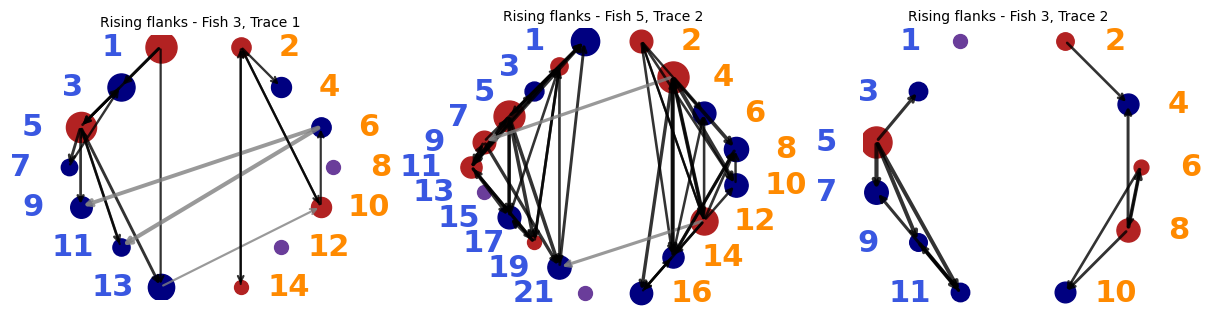

Case A; Fish 3 trace 1; fall: W_IC=0.34844788234721125
Case A; Fish 5 trace 2; fall: W_IC=None
Case A; Fish 3 trace 2; fall: W_IC=0.0
Saved /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/Fall1.png


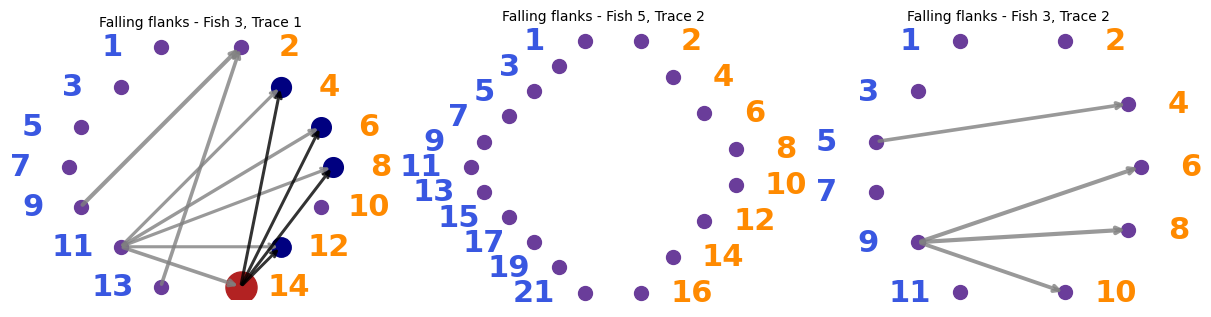

Case B: bad neurons removed; artefacts retained
Case B; Fish 3 trace 1; rise: W_IC=0.7998253571438753
Case B; Fish 5 trace 2; rise: W_IC=0.9533652952742512
Case B; Fish 3 trace 2; rise: W_IC=1.0
Saved /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/Rise2.png


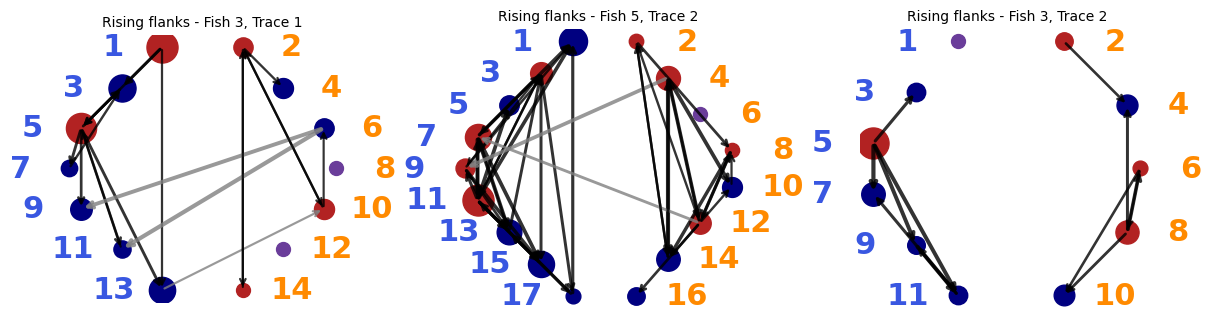

Case B; Fish 3 trace 1; fall: W_IC=0.34844788234721125
Case B; Fish 5 trace 2; fall: W_IC=1.0
Case B; Fish 3 trace 2; fall: W_IC=0.0
Saved /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/Fall2.png


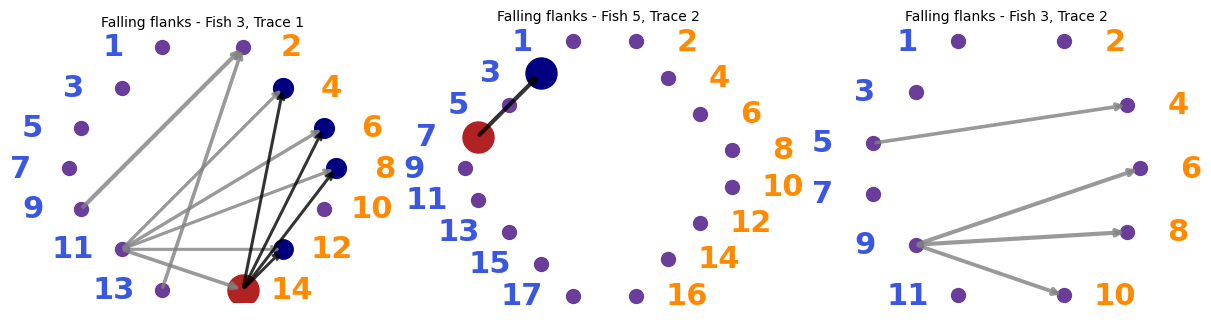

Case C: bad neurons and artefacts removed
Case C; Fish 3 trace 1; rise: W_IC=0.789763255904713
Case C; Fish 5 trace 2; rise: W_IC=0.8825575353416504
Case C; Fish 3 trace 2; rise: W_IC=0.9297199719922175
Saved /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/Rise3.png


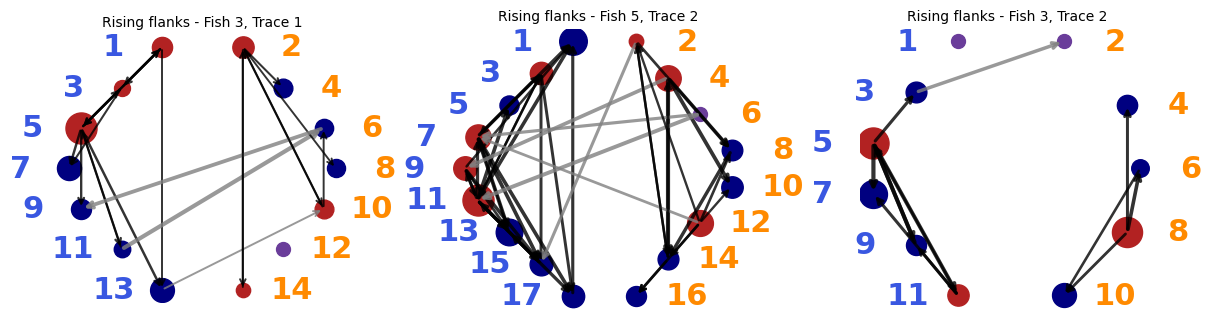

Case C; Fish 3 trace 1; fall: W_IC=0.2728511247639282
Case C; Fish 5 trace 2; fall: W_IC=0.7698229899087784
Case C; Fish 3 trace 2; fall: W_IC=0.0
Saved /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/Fall3.png


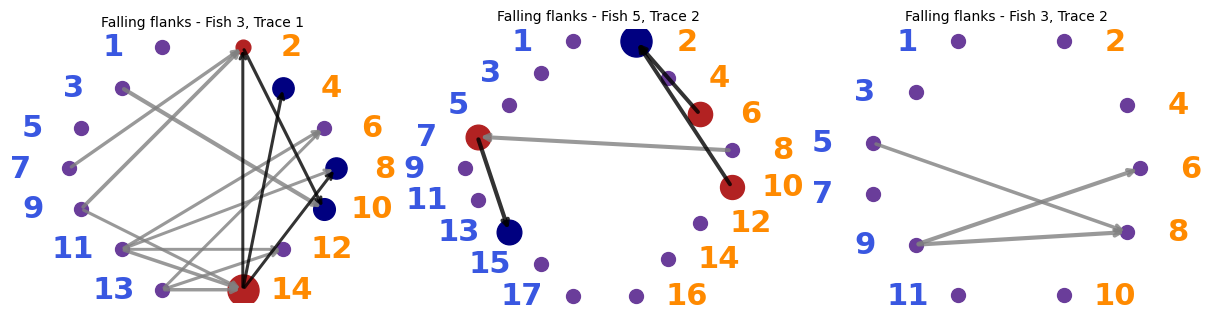

Case D: corrected traces smoothed
Case D; Fish 3 trace 1; rise: W_IC=0.1525238015261851
Case D; Fish 5 trace 2; rise: W_IC=0.10606615427453821
Case D; Fish 3 trace 2; rise: W_IC=0.5163624871772556
Saved /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/Rise4.png


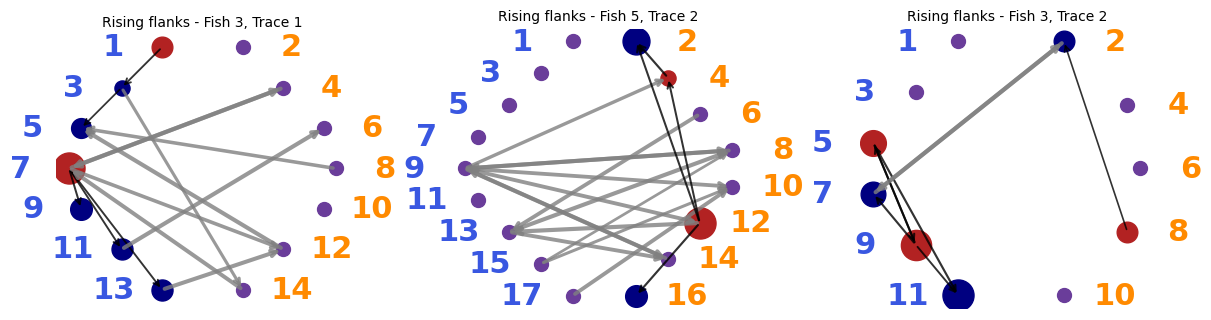

Case D; Fish 3 trace 1; fall: W_IC=0.27010866419326485
Case D; Fish 5 trace 2; fall: W_IC=1.0
Case D; Fish 3 trace 2; fall: W_IC=0.0
Saved /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/Fall4.png


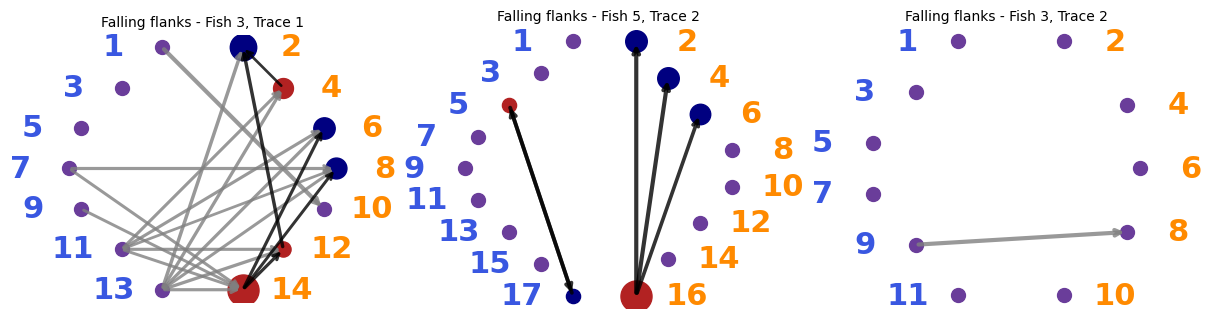

In [6]:
# Reproduce manuscript Figures 4 and 5 style from weighted adjacency matrices.
# This uses the abstract bilateral graph layout, not anatomical backgrounds.
# It also writes figures/Rise1.png ... figures/Fall4.png for direct manuscript use.


def ensure_cached_cases_loaded():
    if "cases" not in globals() or not cases:
        cache = adjacency_cache if "adjacency_cache" in globals() else load_adjacency_cache()
        return attach_cached_graphs({}, cache)
    missing_graphs = [label for label, case in cases.items() if "graphs" not in case]
    if missing_graphs:
        cache = adjacency_cache if "adjacency_cache" in globals() else load_adjacency_cache()
        return attach_cached_graphs(cases, cache)
    return cases


def plot_case_phase(case_label, phase, *, save=True):
    case = cases[case_label]
    phase_label = "Rising" if phase == "rise" else "Falling"
    fig, axes = plt.subplots(1, len(PLOT_KEYS), figsize=(12, 4), constrained_layout=True)
    for ax, key in zip(axes, PLOT_KEYS):
        matrix = np.asarray(case["graphs"][key][phase].retained_scores, dtype=float)
        plot_directed_graph(matrix, case["middle"][key], ax=ax)
        title = f"{phase_label} flanks - Fish {key[0]}, Trace {key[1]}"
        ax.set_title(title, fontsize=10)
        score = get_ratio_from_GC(matrix, mid=case["middle"][key], ratio_type="ipsi")
        print(f"Case {case_label}; Fish {key[0]} trace {key[1]}; {phase}: W_IC={score}")
    if save:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        prefix = "Rise" if phase == "rise" else "Fall"
        figure_path = FIGURE_DIR / f"{prefix}{CASE_FIGURE_INDEX[case_label]}.png"
        fig.savefig(figure_path, dpi=300, bbox_inches="tight")
        print(f"Saved {figure_path}")
    plt.show()
    return fig, axes


cases = ensure_cached_cases_loaded()
for case_label in CASE_FILES:
    print(f"Case {case_label}: {cases[case_label]['description']}")
    plot_case_phase(case_label, "rise", save=True)
    plot_case_phase(case_label, "fall", save=True)
